---

# SCATTERPLOTS & BUBBLE CHARTS

---

>---
>**Scatterplots** are used to visualize the relationship between numerical variables.
>
>- **`ax.scatter(`** `x-axis series`, `y-axis series`, `size=`, `alpha=` `)`
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<br><br>

---

## SCATTERPLOTS

In [2]:
df = pd.read_csv('../Data/Diamonds Prices2022.csv')

df = df.reindex(columns=['carat', 'cut', 'color', 'clarity', 
                         'depth', 'table','price'])

display(df.head(3))

,carat,cut,color,clarity,depth,table,price
0,0.23,Ideal,E,SI2,61.5,55.0,326
1,0.21,Premium,E,SI1,59.8,61.0,326
2,0.23,Good,E,VS1,56.9,65.0,327


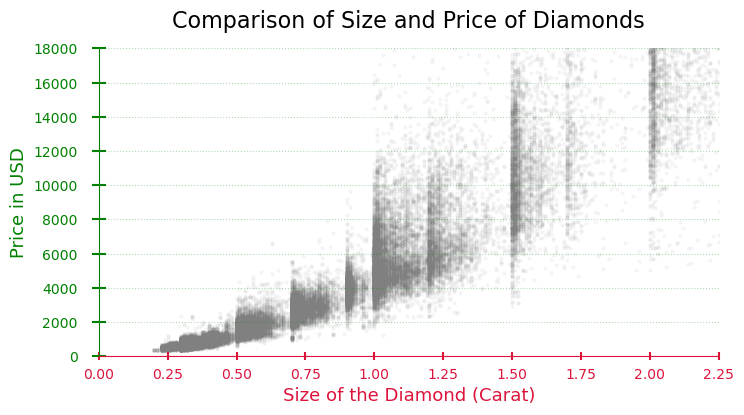

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(x=df.carat, y=df.price, 
           s=5, c='gray', alpha=0.05)

ax.set_xlim(0, 2.25)
ax.set_ylim(0, 18000)

ax.set_title('Comparison of Size and Price of Diamonds', 
             fontsize=16, c='black', pad=15)
ax.set_xlabel('Size of the Diamond (Carat)', 
              fontsize=13, c='crimson')
ax.set_ylabel('Price in USD', 
              fontsize=13, c='green')

ax.grid(axis='y', ls=':', alpha=0.3, c='green')

ax.tick_params(axis='x', color='crimson', direction='inout',
               length=6, width=1.5, pad=5, labelrotation=0,
               colors='crimson')
ax.tick_params(axis='y', color='green', direction='inout',
               length=10, width=1.5, pad=10, labelrotation=0,
               colors='green')

ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_color('green')
ax.spines['bottom'].set_color('crimson')
plt.show()

<br><br>


---

## LABORATORY



In [4]:
df1 = pd.read_csv('../Data/ca_housing.csv', parse_dates=['period_begin', 'period_end'])
df1 = df1.query("region_name == 'Los Angeles'")
df1.head()

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
0,Los Angeles,2018-08-20,2018-11-11,16015.0,20026.0,21675.0,51.9,694662.5,16.528985
1,Los Angeles,2017-12-25,2018-03-18,13596.0,13817.0,15251.0,51.3,664516.6,13.834214
2,Los Angeles,2019-01-21,2019-04-14,13372.0,18580.0,20097.0,58.2,697324.3,18.764906
5,Los Angeles,2021-01-11,2021-04-04,16826.0,12843.0,14557.0,44.8,885070.2,10.588778
6,Los Angeles,2018-06-11,2018-09-02,18662.0,18795.0,20562.0,44.7,698266.6,13.374101


In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 278 entries, 0 to 833
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   region_name               278 non-null    object        
 1   period_begin              278 non-null    datetime64[ns]
 2   period_end                278 non-null    datetime64[ns]
 3   total_homes_sold          278 non-null    float64       
 4   inventory                 278 non-null    float64       
 5   active_listings           278 non-null    float64       
 6   age_of_inventory          278 non-null    float64       
 7   median_active_list_price  278 non-null    float64       
 8   months_of_supply          278 non-null    float64       
dtypes: datetime64[ns](2), float64(6), object(1)
memory usage: 21.7+ KB


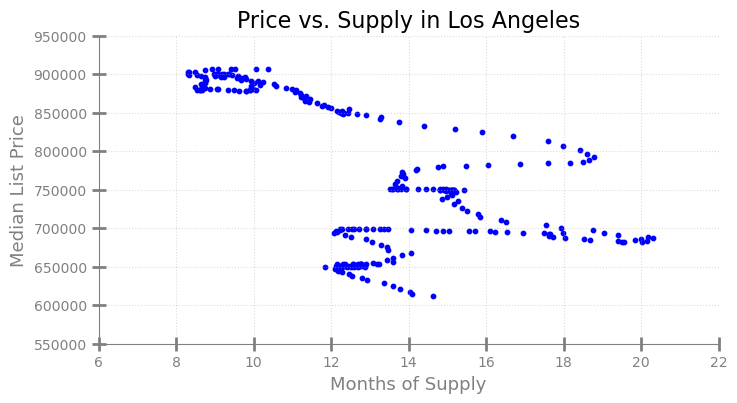

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(x=df1.months_of_supply, 
           y=df1.median_active_list_price,
           s=10, color='blue')

ax.set_xlim(6, 22)
ax.set_ylim(550000, 950000)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color('gray')
ax.grid(axis='both', ls=':', alpha=0.45)

ax.tick_params(axis='both', direction='inout',
               length=10, width=2, color='gray',
               colors='gray')


ax.set_title('Price vs. Supply in Los Angeles', fontsize=16)
ax.set_xlabel('Months of Supply', fontsize=13, color='gray')
ax.set_ylabel('Median List Price', fontsize=13, color='gray')

plt.show()

<br><br>

---

## BUBBLE CHARTS

>---
>To create a **bubble chart**, specify a third series in the "size" argument of `.scatter()`
>
>- You may need to apply some arithmetic to adjust to bubble sizes
>
>---

In [7]:
df1.head()

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply
0,Los Angeles,2018-08-20,2018-11-11,16015.0,20026.0,21675.0,51.9,694662.5,16.528985
1,Los Angeles,2017-12-25,2018-03-18,13596.0,13817.0,15251.0,51.3,664516.6,13.834214
2,Los Angeles,2019-01-21,2019-04-14,13372.0,18580.0,20097.0,58.2,697324.3,18.764906
5,Los Angeles,2021-01-11,2021-04-04,16826.0,12843.0,14557.0,44.8,885070.2,10.588778
6,Los Angeles,2018-06-11,2018-09-02,18662.0,18795.0,20562.0,44.7,698266.6,13.374101


In [8]:
min_val = df1.median_active_list_price.min()
max_val = df1.median_active_list_price.max()

print(f'Minimum value: {min_val}\nMaximum Value: {max_val}')

Minimum value: 611561.0
Maximum Value: 906786.5


In [9]:
df1['median_price_scaled'] = (df1.median_active_list_price - min_val) / (max_val - min_val)
df1

,region_name,period_begin,period_end,total_homes_sold,inventory,active_listings,age_of_inventory,median_active_list_price,months_of_supply,median_price_scaled
0,Los Angeles,2018-08-20,2018-11-11,16015.0,20026.0,21675.0,51.9,694662.5,16.528985,0.281485
1,Los Angeles,2017-12-25,2018-03-18,13596.0,13817.0,15251.0,51.3,664516.6,13.834214,0.179373
2,Los Angeles,2019-01-21,2019-04-14,13372.0,18580.0,20097.0,58.2,697324.3,18.764906,0.290501
5,Los Angeles,2021-01-11,2021-04-04,16826.0,12843.0,14557.0,44.8,885070.2,10.588778,0.926442
6,Los Angeles,2018-06-11,2018-09-02,18662.0,18795.0,20562.0,44.7,698266.6,13.374101,0.293693
...,...,...,...,...,...,...,...,...,...,...
820,Los Angeles,2020-08-31,2020-11-22,18806.0,16937.0,18794.0,43.8,852500.0,12.148381,0.816119
824,Los Angeles,2017-10-23,2018-01-14,16051.0,14528.0,16034.0,60.1,653345.8,12.367204,0.141535
825,Los Angeles,2022-01-10,2022-04-03,15264.0,9484.0,10966.0,33.3,894627.5,8.735714,0.958815
829,Los Angeles,2017-01-23,2017-04-16,15603.0,15834.0,17518.0,50.5,620644.3,13.770815,0.030767


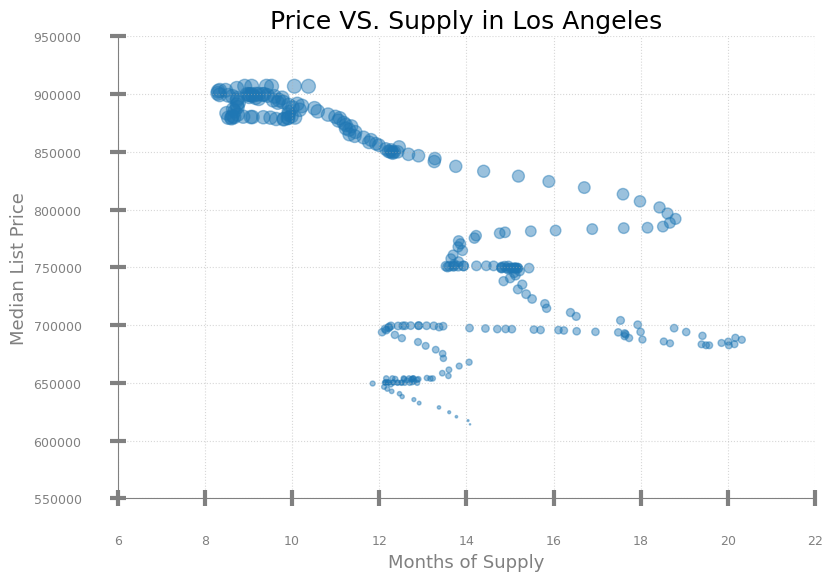

In [29]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(x=df1.months_of_supply, y=df1.median_active_list_price, 
           s= (df1.median_price_scaled*100),
           alpha = 0.45)
ax.set_xlim(6,22)
ax.set_ylim(550000, 950000)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('gray')

ax.tick_params(axis='both', direction='inout',
               length=12, width=3, color='gray',
               colors='gray', labelsize=9, pad=20)

ax.grid(axis='both', ls=':', alpha=0.5)

ax.set_title('Price VS. Supply in Los Angeles', fontsize=18)
ax.set_xlabel('Months of Supply', fontsize=13, color='gray')
ax.set_ylabel('Median List Price', fontsize=13, color='gray')

plt.show()